<a href="https://colab.research.google.com/github/evany50/Cloud-Storage-Benchmark/blob/main/CS_4740_Semester_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 4740 Semester Project

In [ ]:
!pip install "boto3==1.24.96" "botocore==1.27.96"

[small] B2 - Avg Upload: 0.343s, Avg Download: 0.318s
[small] R2 - Avg Upload: 0.648s, Avg Download: 0.487s
[small] IBM - Avg Upload: 0.404s, Avg Download: 0.56s
[medium] B2 - Avg Upload: 0.68s, Avg Download: 0.421s
[medium] R2 - Avg Upload: 1.283s, Avg Download: 0.68s
[medium] IBM - Avg Upload: 0.804s, Avg Download: 0.48s
[large] B2 - Avg Upload: 1.401s, Avg Download: 0.907s
[large] R2 - Avg Upload: 1.906s, Avg Download: 1.59s
[large] IBM - Avg Upload: 1.591s, Avg Download: 1.143s


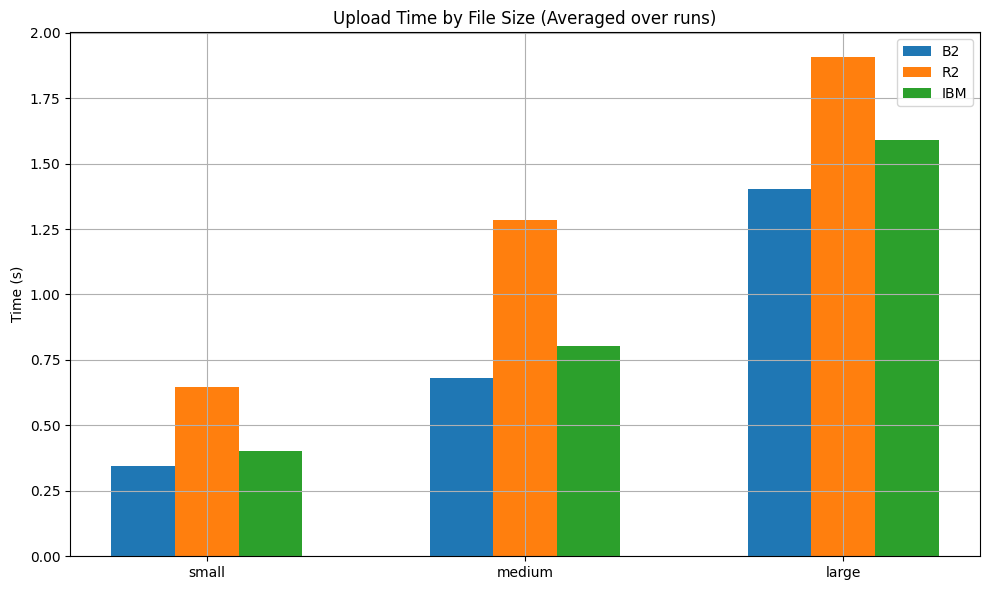

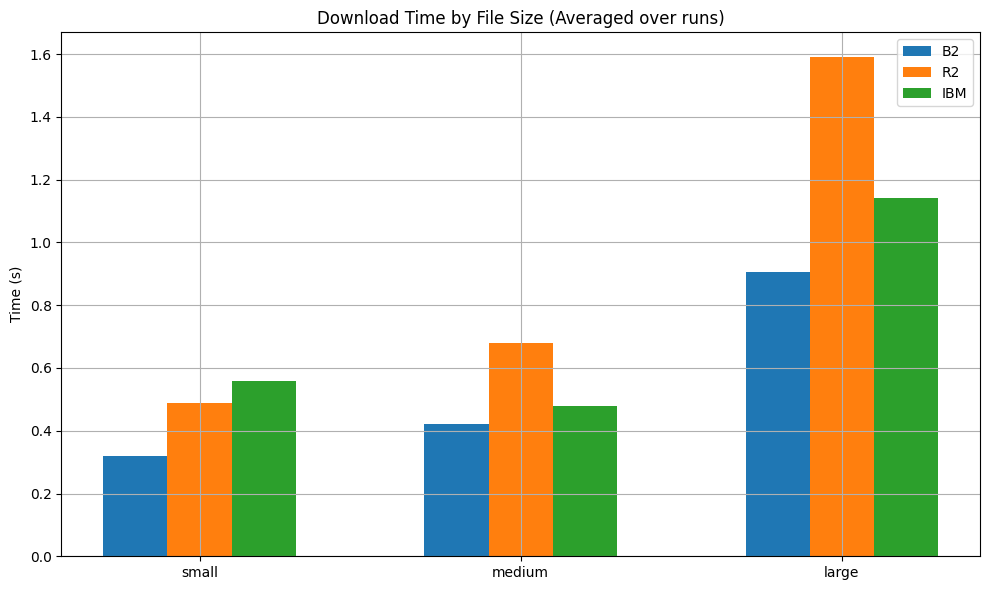

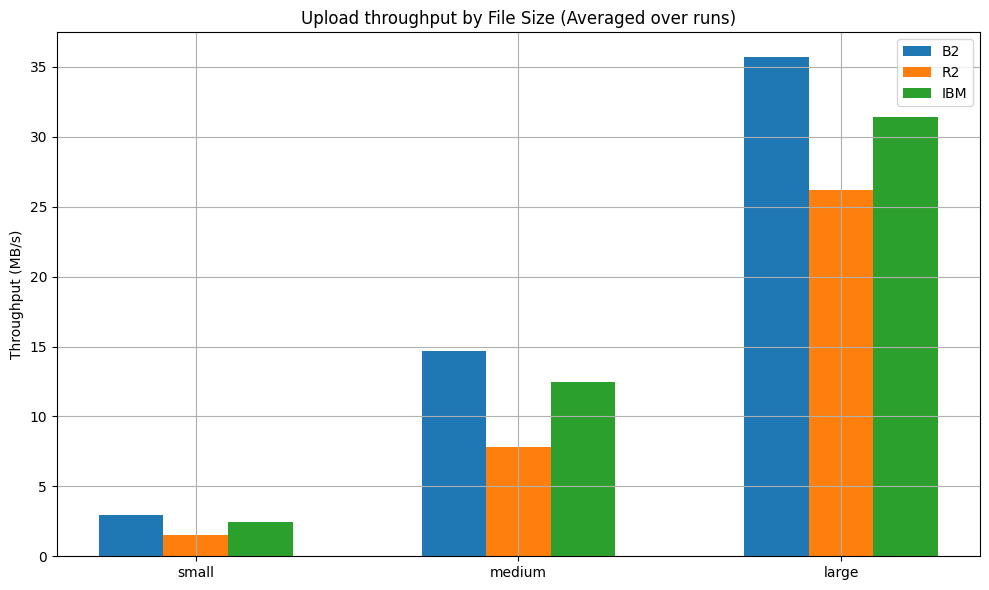

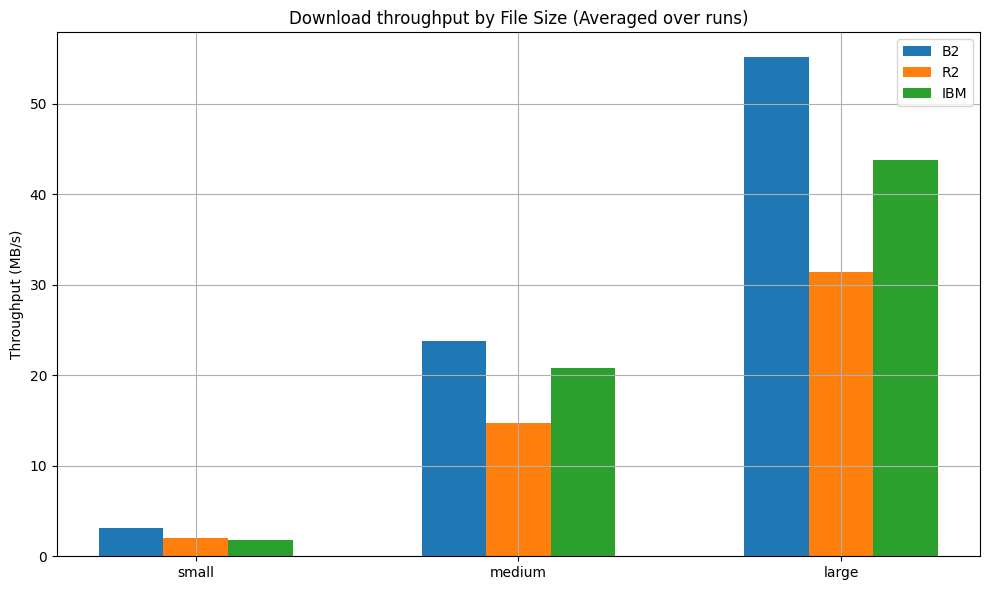

In [ ]:
import boto3
import time
import os
import matplotlib.pyplot as plt
from botocore.client import Config
from google.colab import userdata
from collections import defaultdict

# Config for each provider
PROVIDERS = {
    'b2': {
        'endpoint': 'https://s3.us-east-005.backblazeb2.com',
        'bucket': 'cs4740-b2',
        'access_key': userdata.get('B2_ACCESS_KEY'),
        'secret_key': userdata.get('B2_SECRET_KEY'),
        'region': 'us-east-005'
    },
    'r2': {
        'endpoint': 'https://12e0842cb0d4f64d9cb8dfe881d146f7.r2.cloudflarestorage.com',
        'bucket': 'cs4740-cloudfare',
        'access_key': userdata.get('R2_ACCESS_KEY'),
        'secret_key': userdata.get('R2_SECRET_KEY'),
        'region': 'auto'
    },
    'ibm': {
        'endpoint': 'https://s3.us-east.cloud-object-storage.appdomain.cloud',
        'bucket': 'cs4740-ibm',
        'access_key': userdata.get('IBM_ACCESS_KEY'),
        'secret_key': userdata.get('IBM_SECRET_KEY'),
        'region': 'us-east'
    }
}

# Files to test
FILES = {
    'small': 'test_1MB.txt',
    'medium': 'test_10MB.txt',
    'large': 'test_50MB.txt'
}

def upload_file(provider_name, config, file_path, object_name):
    session = boto3.session.Session()
    s3 = session.client('s3',
        region_name=config['region'],
        endpoint_url=config['endpoint'],
        aws_access_key_id=config['access_key'],
        aws_secret_access_key=config['secret_key'],
        config=Config(signature_version='s3v4', s3={'addressing_style': 'path'})
    )
    start = time.perf_counter()
    s3.upload_file(file_path, config['bucket'], object_name)
    end = time.perf_counter()
    return round(end - start, 3)

def download_file(provider_name, config, object_name, file_path):
    session = boto3.session.Session()
    s3 = session.client('s3',
        region_name=config['region'],
        endpoint_url=config['endpoint'],
        aws_access_key_id=config['access_key'],
        aws_secret_access_key=config['secret_key'],
        config=Config(signature_version='s3v4', s3={'addressing_style': 'path'})
    )
    start = time.perf_counter()
    s3.download_file(config['bucket'], object_name, file_path)
    end = time.perf_counter()
    return round(end - start, 3)

def run_benchmark(runs=3):
    results = {'upload': {}, 'download': {}, 'upload_throughput': {}, 'download_throughput': {}}
    size_map = {'small': 1, 'medium': 10, 'large': 50}

    for label, file_path in FILES.items():
        file_size_mb = size_map[label]
        if not os.path.exists(file_path):
            with open(file_path, 'wb') as f:
                f.write(os.urandom(file_size_mb * 1_000_000))

        for provider, cfg in PROVIDERS.items():
            upload_times = []
            download_times = []

            object_name = f"{label}_{file_path}"
            for _ in range(runs):
                upload_time = upload_file(provider, cfg, file_path, object_name)
                download_time = download_file(provider, cfg, object_name, f"downloaded_{object_name}")
                upload_times.append(upload_time)
                download_times.append(download_time)

            avg_upload = round(sum(upload_times) / runs, 3)
            avg_download = round(sum(download_times) / runs, 3)
            upload_tp = round(file_size_mb / avg_upload, 2)
            download_tp = round(file_size_mb / avg_download, 2)

            results['upload'].setdefault(label, {})[provider] = avg_upload
            results['download'].setdefault(label, {})[provider] = avg_download
            results['upload_throughput'].setdefault(label, {})[provider] = upload_tp
            results['download_throughput'].setdefault(label, {})[provider] = download_tp

            print(f"[{label}] {provider.upper()} - Avg Upload: {avg_upload}s, Avg Download: {avg_download}s")

    return results

def plot_bar_charts(results):
    labels = list(FILES.keys())
    providers = list(PROVIDERS.keys())
    x = range(len(labels))
    width = 0.2

    for op_type in ['upload', 'download']:
        plt.figure(figsize=(10, 6))
        for idx, provider in enumerate(providers):
            times = [results[op_type][label][provider] for label in labels]
            plt.bar([p + width*idx for p in x], times, width, label=provider.upper())
        plt.xticks([p + width for p in x], labels)
        plt.ylabel("Time (s)")
        plt.title(f"{op_type.capitalize()} Time by File Size (Averaged over runs)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    for tp_type in ['upload_throughput', 'download_throughput']:
        plt.figure(figsize=(10, 6))
        for idx, provider in enumerate(providers):
            throughputs = [results[tp_type][label][provider] for label in labels]
            plt.bar([p + width*idx for p in x], throughputs, width, label=provider.upper())
        plt.xticks([p + width for p in x], labels)
        plt.ylabel("Throughput (MB/s)")
        plt.title(f"{tp_type.replace('_', ' ').capitalize()} by File Size (Averaged over runs)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

benchmark_results = run_benchmark(runs=5)
plot_bar_charts(benchmark_results)

